In [1]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
X, y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [45]:
#df = pd.DataFrame({'feature1':X[:,0],'target':'y'})
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':'y'})

In [46]:
df.head(5)

,feature1,feature2,target
0,-0.724350,-1.353568,y
1,0.024198,-0.391965,y
2,-0.142204,-0.484716,y
3,0.110145,0.360482,y
4,0.523598,-0.726412,y


In [47]:
df.shape

(100, 3)

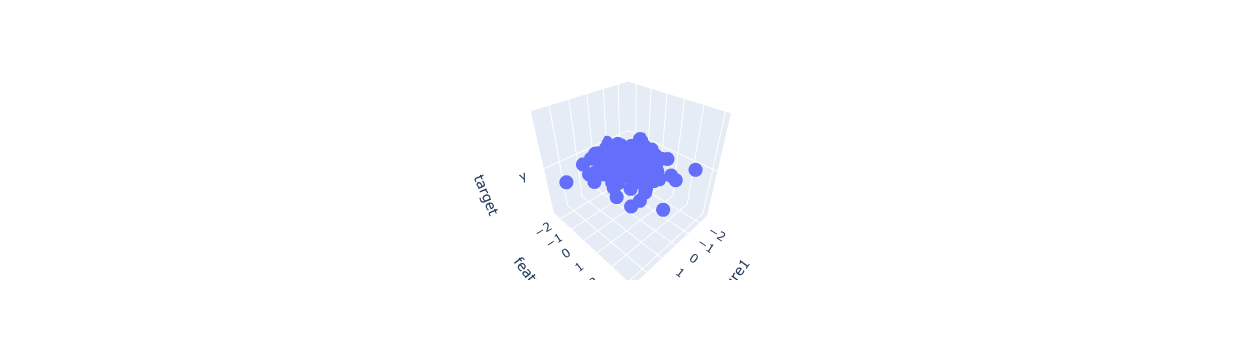

In [49]:
#fig = px.scatter(x=df['feature1'],  y=df['target'])
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.show()

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [10]:
len(X_train)

80

In [11]:
len(X_test)

20

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = lr.predict(X_test)

In [14]:
y_pred

array([-123.72898653,  -31.52910941,  -31.09398027,  144.55913232,
       -148.21053098,  -16.07916945,   43.1896103 ,   60.43508923,
         23.03537321,   77.87817571,   -3.98943522, -157.91338051,
        144.10265392,  -11.4716613 ,   97.71588038, -110.85293893,
        -30.93047443,  -74.47989979,  148.75778394,   49.44807047])

In [15]:
y_test

array([ -96.76624361,  -76.71813088,    7.75839902,   89.12207989,
       -117.18162723,  -70.701894  ,  149.94338143,  108.81112341,
        -34.67260194,  164.70865382,   83.07254214, -191.12654305,
         91.26975988,  -58.84904798,   36.25118531, -109.78765518,
         -4.69808553, -149.53186341,  147.69312251,   17.27736102])

In [16]:
print('MAE: ', mean_absolute_error(y_test,y_pred))
print('MSE: ', mean_squared_error(y_test,y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2-score: ', r2_score(y_test,y_pred))

MAE:  48.464810290497596
MSE:  3037.9748753337276
RMSE:  55.11782720076806
R2-score:  0.7209173896422899


In [17]:
lr.coef_

array([83.03677865, 21.23620075])

In [19]:
lr.intercept_

np.float64(4.378753058506055)

In [22]:
#Calculating R-Squared
lr.score(X_train,y_train)

0.7363284768899665

### Formula for Adjusted R^2

$R^2_{adj.} = 1 - (1-R^2)*\frac{n-1}{n-p-1}$

In [24]:
X_train.shape

(80, 2)

In [26]:
r2 = lr.score(X_train,y_train)
n = X_train.shape[0]
p = X_train.shape[1]

adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
adjusted_r2

0.7294798659000955

In [27]:
import statsmodels.api as sm
x1 = sm.add_constant(X_train)
results = sm.OLS(y_train,x1).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     107.5
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           5.14e-23
Time:                        11:54:59   Log-Likelihood:                -428.44
No. Observations:                  80   AIC:                             862.9
Df Residuals:                      77   BIC:                             870.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3788      5.900      0.742      0.460      -7.370      16.127
x1            83.0368      6.070     13.680      0.000      70.950      95.124
x2            21.2362      5.978      3.552      0.001       9.332      33.140
==============================================================================
Omnibus:                        0.654   Durbin-Watson:                   2.311
Prob(Omnibus):                  0.721   Jarque-Bera (JB):                0.312
Skew:                           0.138   Prob(JB):                        0.856
Kurtosis:                       3.131   Cond. No.                         1.20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""